# Processamento e Fusão do Dataset Final (Humanos + IA)

Nesta secção, concluímos a construção do nosso *dataset* de treino através da extração de textos reais e da sua integração com os textos sintéticos previamente gerados. 

Para garantir a qualidade e a integridade dos dados, este processo está dividido em duas fases rigorosas:

In [2]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

### Fase 1: Limpeza e Extração de Textos Humanos
Como os textos reais (resumos de artigos científicos) possuem formatos imprevisíveis, o primeiro bloco de código encarrega-se de:
* **Filtragem de Origem:** Isolar apenas os textos garantidamente escritos por humanos (`is_ai_generated == 0`).
* **Limpeza Estrutural:** Remover quebras de linha (`\n`, `\r`) e substituir eventuais pontos e vírgulas (`;`) por vírgulas, evitando que o separador do formato CSV final seja quebrado.
* **Filtro de Extensão (80 a 120 palavras):** Aplicar uma restrição matemática estrita para garantir que os textos têm volume suficiente para extração de características (features), eliminando todos os casos fora deste intervalo.

In [13]:
try:
    df = pd.read_csv('dataset_human.csv' , sep=',')
    
    # 2. Extrair apenas os textos escritos por humanos - is_ai_generated == 0 (ou ai_generated == False)
    df_humanos = df[df['is_ai_generated'] == 0].copy()
    
    total_humanos_bruto = len(df_humanos)
    print(f"Total de textos estritamente humanos encontrados: {total_humanos_bruto}")
    
    print("A limpar quebras de linha e pontos e vírgulas dos textos")
    
    # 3. Função para limpar cada texto
    def limpar_texto(texto):
        texto = str(texto)
        # Substituir ponto e vírgula por vírgula (para não partir as colunas)
        texto = texto.replace(';', ',')
        # Remover quebras de linha e retornos
        texto = texto.replace('\n', ' ').replace('\r', '')
        # Remover espaços duplos que possam ter ficado
        texto = re.sub(r'\s+', ' ', texto).strip()
        return texto

    df_humanos['abstract_clean'] = df_humanos['abstract'].apply(limpar_texto)
    
    # 4. Contar as palavras e aplicar a régua (80 a 120)
    df_humanos['word_count'] = df_humanos['abstract_clean'].apply(lambda x: len(x.split()))
    
    df_validos = df_humanos[(df_humanos['word_count'] >= 80) & (df_humanos['word_count'] <= 120)].copy()
    
    total_validos = len(df_validos)
    print(f"Total de textos humanos com o tamanho correto (80-120 palavras): {total_validos}")
    
    # Calcular quantos foram deitados fora
    print(f"Textos rejeitados por tamanho incorreto: {total_humanos_bruto - total_validos}\n")
    
    if total_validos > 0:
        # 5. Preparar o formato final para juntar aos outros
        df_final = pd.DataFrame()
        
        # Criar os IDs sequenciais (ex: HUM-0001, HUM-0002...)
        df_final['ID'] = [f"HUM-{i+1:04d}" for i in range(total_validos)]
        
        # Adicionar o texto limpo e a label
        df_final['Text'] = df_validos['abstract_clean'].values
        df_final['Label'] = 'Human'
        
        # 6. Guardar com o separador ';'
        df_final.to_csv('dataset_human_limpo.csv', sep=';', index=False)
        print(f"O ficheiro '{'dataset_human_limpo.csv'}' foi guardado!")
        print(f"Estrutura gerada: {list(df_final.columns)}")
    else:
        print("Nenhum texto cumpriu os requisitos de tamanho.")

except FileNotFoundError:
    print(f"O ficheiro '{'dataset_human.csv'}' não foi encontrado.")
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")

Total de textos estritamente humanos encontrados: 2100
A limpar quebras de linha e pontos e vírgulas dos textos
Total de textos humanos com o tamanho correto (80-120 palavras): 892
Textos rejeitados por tamanho incorreto: 1208

O ficheiro 'dataset_human_limpo.csv' foi guardado!
Estrutura gerada: ['ID', 'Text', 'Label']


### Fase 2: Concatenação, Baralhamento e Formatação
Com os dados humanos isolados e limpos, o segundo bloco de código finaliza o *dataset*:
* **Fusão de Classes:** Junta os ficheiros de texto humano com o *dataset* contendo as 4 classes de IA (OpenAI, Anthropic, Google, Meta).
* **Dupla Validação:** Executa uma verificação final de segurança no tamanho de todos os textos.
* **Baralhamento (*Shuffle*):** Mistura completamente as linhas do *DataFrame* (`frac=1`) para destruir a ordem cronológica ou de classe original, garantindo que o modelo não aprende enviesamentos baseados na posição da linha.
* **Padronização de IDs:** Reescreve os identificadores de forma sequencial no formato final exigido (`D1-0001`, `D1-0002`, etc.), exportando o *dataset* limpo e pronto para a fase de treino.

In [14]:
ficheiros_csv = [
    'dataset_human_limpo.csv', 
    'dataset_ai.csv'      
]

dfs = []

# Carregar todos os ficheiros da lista
for ficheiro in ficheiros_csv:
    try:
        df_temp = pd.read_csv(ficheiro, sep=';')
        dfs.append(df_temp)
        print(f"Ficheiro '{ficheiro}' carregado com sucesso.")
    except Exception as e:
        print(f"Erro ao ler '{ficheiro}': {e}")

# Juntar tudo num único DataFrame bruto
df_bruto = pd.concat(dfs, ignore_index=True)
print(f"\nTotal de linhas juntas antes da filtragem: {len(df_bruto)}")

# 2. FILTRAGEM 80 a 120 palavras
# Cria uma coluna temporária com a contagem de palavras
df_bruto['WordCount'] = df_bruto['Text'].astype(str).apply(lambda x: len(x.split()))

# Fica apenas com as linhas que estão no range permitido
df_filtrado = df_bruto[(df_bruto['WordCount'] >= 80) & (df_bruto['WordCount'] <= 120)].copy()
linhas_removidas = len(df_bruto) - len(df_filtrado)

print(f"Textos eliminados por não terem entre 80 e 120 palavras: {linhas_removidas}")
print(f"Textos perfeitos que passaram no filtro: {len(df_filtrado)}")

# 3. MISTURAR TUDO (Shuffle)
# frac=1 significa baralhar 100% das linhas; random_state=42 garante reprodutibilidade
df_misturado = df_filtrado.sample(frac=1, random_state=42).reset_index(drop=True)

# 4. REESCREVER OS IDs no formato D1-0001, D1-0002, etc.
df_misturado['ID'] = [f"D1-{i+1:04d}" for i in range(len(df_misturado))]

# 5. LIMPAR E GUARDAR
df_final = df_misturado[['ID', 'Text', 'Label']]

nome_ficheiro_final = 'dataset_final.csv'
df_final.to_csv(nome_ficheiro_final, sep=';', index=False)

print(f"\nO dataset final está guardado como '{nome_ficheiro_final}'.")
print("\nDistribuição final das classes no dataset:")
print(df_final['Label'].value_counts())

Ficheiro 'dataset_human_limpo.csv' carregado com sucesso.
Ficheiro 'dataset_ai.csv' carregado com sucesso.

Total de linhas juntas antes da filtragem: 7492
Textos eliminados por não terem entre 80 e 120 palavras: 494
Textos perfeitos que passaram no filtro: 6998

O dataset final está guardado como 'dataset_final.csv'.

Distribuição final das classes no dataset:
Label
OpenAI       1583
Google       1582
Meta         1544
Anthropic    1397
Human         892
Name: count, dtype: int64


In [15]:
df_final.head()

,ID,Text,Label
0,D1-0001,Photocatalytic water splitting uses semiconduc...,Anthropic
1,D1-0002,Placental pathology provides critical informat...,Anthropic
2,D1-0003,Surgical pathology involves the examination of...,Meta
3,D1-0004,The configuration space network (CSN) of a dyn...,Human
4,D1-0005,The pathology of aging focuses on the biologic...,Meta


In [16]:
df_final.shape

(6998, 3)

##### ESTATÍSTICAS (Categóricas)

In [29]:
display(df_final.describe(include=['O']).T)

C:\Users\dirod\AppData\Local\Temp\ipykernel_8624\1403009569.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df_final.describe(include=['O']).T)


,count,unique,top,freq
ID,6998,6998,D1-0001,1
Text,6998,6996,"In this paper, we consider the coordination co...",2
Label,6998,5,OpenAI,1583


##### Em cima vê-se que 2 textos estão repetidos, em baixo dá 0 porque a linha inteira não é igual por causa do ID

In [28]:
print(df_final.duplicated().sum())

0


In [30]:
textos_repetidos = df_final[df_final.duplicated(subset=['Text'], keep=False)]
display(textos_repetidos)

,ID,Text,Label
1299,D1-1300,"In this paper, we consider the coordination co...",Human
4842,D1-4843,Zero-divisors (ZDs) derived by Cayley-Dickson ...,Human
5199,D1-5200,"In this paper, we consider the coordination co...",Human
5359,D1-5360,Zero-divisors (ZDs) derived by Cayley-Dickson ...,Human


In [31]:
df_final = df_final.drop_duplicates(subset=['Text']).reset_index(drop=True)

# Como apagámos 2 linhas, os IDs ficaram com "buracos". Vamos reescrevê-los:
df_final['ID'] = [f"D1-{i+1:04d}" for i in range(len(df_final))]

df_final.to_csv('dataset_final.csv', sep=';', index=False)

In [32]:
display(df_final.describe(include=['O']).T)

C:\Users\dirod\AppData\Local\Temp\ipykernel_8624\1403009569.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df_final.describe(include=['O']).T)


,count,unique,top,freq
ID,6996,6996,D1-0001,1
Text,6996,6996,Photocatalytic water splitting uses semiconduc...,1
Label,6996,5,OpenAI,1583


C:\Users\dirod\AppData\Local\Temp\ipykernel_8624\2586672433.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_final, x='Label', order=target_order, palette="magma")


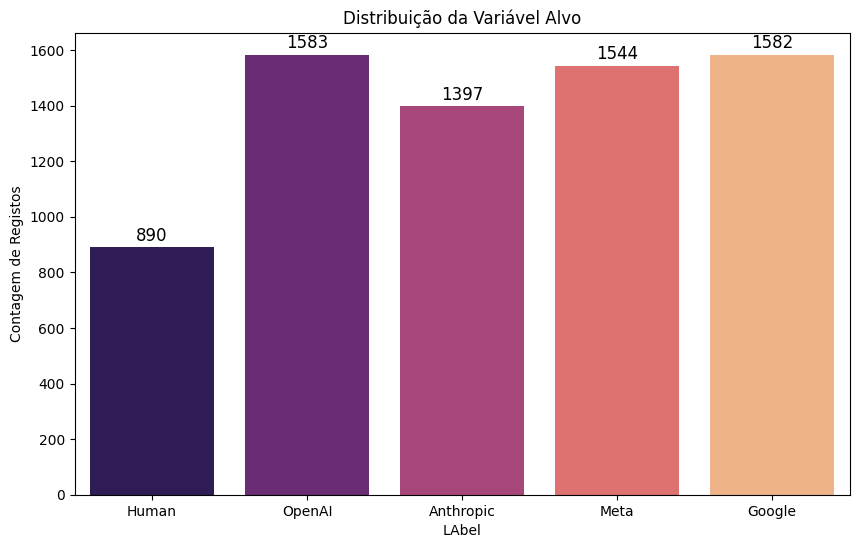

In [33]:
target_order = ['Human', 'OpenAI', 'Anthropic', 'Meta', 'Google']

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_final, x='Label', order=target_order, palette="magma")

plt.title('Distribuição da Variável Alvo')
plt.xlabel('LAbel')
plt.ylabel('Contagem de Registos')

# Adicionar as contagens em cima das barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points')
plt.show()

## Mais dados humanos provenientes da Wikipedia

In [7]:
import wikipedia

wikipedia.set_lang("en")

temas = ["Quantum Mechanics","General Relativity","String Theory","Thermodynamics","Statistical Mechanics","Electromagnetism","Classical Mechanics","Particle Physics","Nuclear Physics","Astrophysics","Cosmology","Dark Matter","Dark Energy","Black Hole","Big Bang","Galaxy Formation","Stellar Evolution","Exoplanet","Solar System","Planetary Science","Geophysics","Seismology","Volcanology","Meteorology","Climatology","Atmospheric Science","Oceanography","Hydrology","Glaciology","Environmental Science","Ecology","Biodiversity","Evolution","Natural Selection","Genetics","Molecular Biology","Cell Biology","Developmental Biology","Neuroscience","Microbiology","Virology","Bacteriology","Immunology","Biochemistry","Proteomics","Genomics","Epigenetics","Synthetic Biology","Systems Biology","Bioinformatics","Biophysics","Structural Biology","Pharmacology","Toxicology","Physiology","Anatomy","Zoology","Botany","Mycology","Entomology","Ornithology","Herpetology","Marine Biology","Paleontology","Archaeology","Anthropology","Linguistics","Cognitive Science","Psychology","Behavioral Science","Sociology","Economics","Game Theory","Decision Theory","Complex Systems","Chaos Theory","Fractal Geometry","Topology", "Algebraic Geometry","Number Theory","Combinatorics","Graph Theory","Linear Algebra","Calculus","Differential Equations","Probability Theory","Statistics","Mathematical Logic","Set Theory","Theoretical Computer Science","Algorithms","Data Structures","Artificial Intelligence","Machine Learning","Deep Learning","Neural Network","Natural Language Processing","Computer Vision","Robotics","Quantum Computing","Distributed Systems","Operating System","Computer Architecture","Information Theory","Cryptography","Cybersecurity","Human-Computer Interaction","Software Engineering","Materials Science","Nanotechnology","Polymer Science","Solid State Physics","Condensed Matter Physics","Surface Science","Crystallography","Spectroscopy","Analytical Chemistry","Organic Chemistry","Inorganic Chemistry","Physical Chemistry","Theoretical Chemistry","Green Chemistry","Electrochemistry","Photochemistry","Radiochemistry","Astrochemistry","Chemical Engineering","Process Engineering","Mechanical Engineering","Civil Engineering","Electrical Engineering","Biomedical Engineering","Aerospace Engineering","Control Theory","Signal Processing","Optics","Photonics","Laser Physics","Acoustics","Fluid Dynamics","Aerodynamics","Plasma Physics","Magnetohydrodynamics","Computational Physics","Computational Biology","Computational Chemistry","Numerical Analysis","Scientific Computing","High Performance Computing","Big Data","Data Science","Information Retrieval","Knowledge Representation","Ontology","Semantic Web","Blockchain","Internet of Things","Edge Computing","Cloud Computing","Augmented Reality","Virtual Reality","Mixed Reality","Digital Signal Processing","Image Processing","Pattern Recognition","Speech Recognition","Reinforcement Learning","Evolutionary Computation","Swarm Intelligence","Fuzzy Logic","Multi-Agent Systems","Decision Support Systems","Operations Research","Supply Chain Management","Logistics","Transportation Engineering","Urban Planning","Geographic Information System","Remote Sensing","Cartography","Geodesy","Geochemistry","Petrology","Mineralogy","Soil Science","Agronomy","Horticulture","Forestry","Food Science","Nutrition Science","Dietetics","Public Health","Epidemiology","Global Health","Health Informatics","Medical Imaging","Radiology","Oncology","Cardiology","Neurology","Endocrinology","Immunotherapy","Regenerative Medicine","Stem Cell Research","Precision Medicine","Genetic Engineering","Biotechnology","Industrial Biotechnology","Environmental Engineering","Sustainable Development","Renewable Energy","Solar Energy","Wind Energy","Hydropower","Geothermal Energy","Energy Storage","Battery Technology","Fuel Cells","Smart Grid"]

textos_humanos = []
ids_count = 1

print("📚 A iniciar extração da Wikipedia com Agrupamento de Frases...\n")

for tema in temas:
    try:
        # Pesquisar a página
        pagina = wikipedia.page(tema, auto_suggest=False)
        
        # 1. Limpar cabeçalhos da Wiki (ex: == History ==) logo à cabeça
        conteudo = re.sub(r'==+.*?==+', '', pagina.content)
        
        # 2. Limpeza brutal de quebras de linha e pontos e vírgulas
        conteudo = conteudo.replace('\n', ' ').replace('\r', '').replace(';', ',')
        conteudo = re.sub(r'\s+', ' ', conteudo).strip()
        
        # 3. O SEGREDO: Separar o texto todo em frases!
        # (O (?<=[.!?]) garante que dividimos no espaço logo a seguir à pontuação, mantendo o ponto na frase)
        frases = re.split(r'(?<=[.!?]) +', conteudo)
        
        chunk_atual = ""
        textos_neste_tema = 0
        
        for frase in frases:
            if not frase: continue
            
            # Simular a junção desta frase ao nosso bloco atual
            teste_chunk = (chunk_atual + " " + frase).strip()
            word_count = len(teste_chunk.split())
            
            if word_count < 75:
                # O bloco ainda está pequeno. Guardamos e vamos buscar a próxima frase.
                chunk_atual = teste_chunk
                
            elif 75 <= word_count <= 130:
                # PERFEITO! Atingimos a zona alvo e a frase está completa.
                palavras = teste_chunk.split()
                primeiras_10 = " ".join(palavras[:10])
                
                textos_humanos.append({
                    "ID": f"WIKI-{ids_count:04d}",
                    "Text": teste_chunk,
                    "Prompt_10_Words": primeiras_10,
                    "Label": "Human",
                    "WordCount": word_count,
                    "Topic": tema
                })
                ids_count += 1
                textos_neste_tema += 1
                
                # Fazer reset ao bloco para começar a construir o próximo texto
                chunk_atual = "" 
                
            else:
                # OVERSHOOT! A frase que tentámos adicionar era gigante e atirou-nos para >130 palavras.
                # Deitamos fora o chunk antigo e começamos um novo bloco a partir desta frase longa.
                chunk_atual = frase
                
        print(f"✅ '{tema}': {textos_neste_tema} textos perfeitos extraídos.")
        
    except wikipedia.exceptions.DisambiguationError:
        pass # Ignorar páginas ambíguas silenciosamente
    except wikipedia.exceptions.PageError:
        pass # Ignorar páginas não encontradas
    except Exception as e:
        print(f"❌ Erro no tema '{tema}': {e}")

# Converter para DataFrame e guardar
df_wiki = pd.DataFrame(textos_humanos)

print(f"\n🎉 EXTRAÇÃO CONCLUÍDA! Foram recolhidos {len(df_wiki)} textos humanos com frases completas.")

if len(df_wiki) > 0:
    df_export = df_wiki[['ID', 'Text', 'Prompt_10_Words', 'Label']]
    nome_ficheiro = "dataset_wiki_humanos.csv"
    df_export.to_csv(nome_ficheiro, sep=';', index=False)
    print(f"💾 Ficheiro guardado como '{nome_ficheiro}'.")

📚 A iniciar extração da Wikipedia com Agrupamento de Frases...

✅ 'Quantum Mechanics': 81 textos perfeitos extraídos.
✅ 'General Relativity': 116 textos perfeitos extraídos.
✅ 'String Theory': 134 textos perfeitos extraídos.
✅ 'Thermodynamics': 51 textos perfeitos extraídos.
✅ 'Statistical Mechanics': 39 textos perfeitos extraídos.
✅ 'Electromagnetism': 26 textos perfeitos extraídos.
✅ 'Classical Mechanics': 59 textos perfeitos extraídos.
✅ 'Particle Physics': 30 textos perfeitos extraídos.
✅ 'Nuclear Physics': 37 textos perfeitos extraídos.
✅ 'Astrophysics': 26 textos perfeitos extraídos.
✅ 'Cosmology': 20 textos perfeitos extraídos.
✅ 'Dark Matter': 94 textos perfeitos extraídos.
✅ 'Dark Energy': 61 textos perfeitos extraídos.
✅ 'Black Hole': 123 textos perfeitos extraídos.
✅ 'Big Bang': 96 textos perfeitos extraídos.
✅ 'Galaxy Formation': 36 textos perfeitos extraídos.
✅ 'Stellar Evolution': 57 textos perfeitos extraídos.
✅ 'Exoplanet': 90 textos perfeitos extraídos.
✅ 'Solar System

c:\Users\Diogo\Desktop\MEI\4ºano\2ºsemestre\Aprendizagem Profunda\Trabalho\Modulo1\.venv\Lib\site-packages\wikipedia\wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("html.parser"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file c:\Users\Diogo\Desktop\MEI\4ºano\2ºsemestre\Aprendizagem Profunda\Trabalho\Modulo1\.venv\Lib\site-packages\wikipedia\wikipedia.py. To get rid of this warning, pass the additional argument 'features="html.parser"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


✅ 'Epidemiology': 64 textos perfeitos extraídos.
✅ 'Global Health': 64 textos perfeitos extraídos.
✅ 'Health Informatics': 109 textos perfeitos extraídos.
✅ 'Medical Imaging': 63 textos perfeitos extraídos.
✅ 'Radiology': 55 textos perfeitos extraídos.
✅ 'Oncology': 18 textos perfeitos extraídos.
✅ 'Cardiology': 66 textos perfeitos extraídos.
✅ 'Neurology': 22 textos perfeitos extraídos.
✅ 'Endocrinology': 26 textos perfeitos extraídos.
✅ 'Immunotherapy': 30 textos perfeitos extraídos.
✅ 'Regenerative Medicine': 25 textos perfeitos extraídos.
✅ 'Stem Cell Research': 75 textos perfeitos extraídos.
✅ 'Precision Medicine': 66 textos perfeitos extraídos.
✅ 'Genetic Engineering': 62 textos perfeitos extraídos.
✅ 'Biotechnology': 46 textos perfeitos extraídos.
✅ 'Industrial Biotechnology': 46 textos perfeitos extraídos.
✅ 'Environmental Engineering': 20 textos perfeitos extraídos.
✅ 'Sustainable Development': 36 textos perfeitos extraídos.
✅ 'Renewable Energy': 100 textos perfeitos extraídos

## Geração de textos de AI com o llhama3 pedindo para completar as frases humanas apartir das 10 primeiras palavras

In [ ]:
import os
from groq import Groq
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

# ==========================================
# 1. CONFIGURAÇÃO DA API GROQ
# ==========================================

MINHA_API_KEY = "" 

# Inicializar o cliente
client = Groq(api_key=MINHA_API_KEY)

# ==========================================
# 2. FUNÇÃO GERADORA (Llama 3)
# ==========================================
def gerar_groq(id_original, prompt_10_words):
    # O Prompt é ditatorial para garantir que a IA não seja "simpática" 
    # e não repita as 10 palavras iniciais, continuando apenas a frase.
    system_prompt = (
        "You are an expert academic writer. I will give you the first 10 words of a paragraph. "
        "You must finish the paragraph seamlessly. "
        "RULES:\n"
        "1. DO NOT repeat the first 10 words I give you. Just provide the continuation.\n"
        "2. DO NOT write conversational filler like 'Here is the continuation' or 'Sure'.\n"
        "3. Write exactly between 80 and 100 words.\n"
        "4. End with a complete sentence."
    )
    
    try:
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant", # O modelo mais barato e rápido
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f"Start of the paragraph: '{prompt_10_words}'"}
            ],
            max_tokens=200,
            temperature=0.7
        )
        
        texto_final = response.choices[0].message.content.strip()
        texto_completo = f"{prompt_10_words} {texto_final}"
        
        # Limpezas do texto
        texto_limpo = texto_completo.replace('\n', ' ').replace('\r', '').replace(';', ',')
        texto_limpo = ' '.join(texto_limpo.split())
        word_count = len(texto_limpo.split())
        
        # Filtrar pela régua do professor (80-120 palavras)
        if 80 <= word_count <= 120:
            return {
                "Original_ID": id_original,
                "Text": texto_limpo,
                "Label": "Meta",
                "WordCount": word_count,
                "Status": "Success"
            }
        else:
            return {"Original_ID": id_original, "Status": "Size_Error"}
            
    except Exception as e:
        return {"Original_ID": id_original, "Status": f"API_Error: {str(e)}"}

# ==========================================
# 3. MOTOR MULTITHREADING
# ==========================================
ficheiro_humanos = 'dataset_wiki_humanos.csv'
ficheiro_saida_ai = 'dataset_ai_groq_fast.csv'

print("🚀 A iniciar a Geração Paralela na Groq...")

try:
    df_humanos = pd.read_csv(ficheiro_humanos, sep=';')
    
    dados_ai = []
    ids_ja_processados = set()
    
    # Retoma de Trabalho (Autosave)
    if os.path.exists(ficheiro_saida_ai):
        df_existente = pd.read_csv(ficheiro_saida_ai, sep=';')
        dados_ai = df_existente.to_dict('records')
        ids_ja_processados = set(df_existente['Original_ID'].tolist())
        print(f"🔄 Retoma: {len(ids_ja_processados)} textos do Llama já gerados.")

    # Descobrir quais faltam gerar
    tarefas_pendentes = df_humanos[~df_humanos['ID'].isin(ids_ja_processados)]
    
    if tarefas_pendentes.empty:
        print("✅ Todos os textos já foram gerados!")
    else:
        print(f"⚡ A enviar {len(tarefas_pendentes)} pedidos para a Groq em simultâneo...")
        
        # O SEGREDO DA VELOCIDADE: 20 trabalhadores (threads) em simultâneo
        with ThreadPoolExecutor(max_workers=20) as executor:
            # Submeter todas as tarefas de uma vez
            futuros = {
                executor.submit(gerar_groq, row['ID'], row['Prompt_10_Words']): row['ID'] 
                for _, row in tarefas_pendentes.iterrows()
            }
            
            # Apanhar os resultados à medida que vão chegando (com barra de progresso)
            for futuro in tqdm(as_completed(futuros), total=len(futuros), desc="A gerar textos"):
                resultado = futuro.result()
                
                if resultado["Status"] == "Success":
                    # Remover o "Status" antes de guardar para o CSV ficar limpo
                    del resultado["Status"]
                    dados_ai.append(resultado)
                
                # Guardar um backup a cada 100 sucessos (Autosave eficiente)
                if len(dados_ai) % 100 == 0:
                    pd.DataFrame(dados_ai).to_csv(ficheiro_saida_ai, sep=';', index=False)

        # Gravação Final Absoluta
        df_final_ai = pd.DataFrame(dados_ai)
        df_final_ai.to_csv(ficheiro_saida_ai, sep=';', index=False)
        print(f"\n🎉 GERAÇÃO CONCLUÍDA! O teu dataset de IA tem {len(df_final_ai)} frases perfeitas prontas para treino.")

except Exception as e:
    print(f"❌ Erro fatal: {e}")

🚀 A iniciar a Geração Paralela na Groq...
⚡ A enviar 10948 pedidos para a Groq em simultâneo...


A gerar textos: 100%|██████████| 10948/10948 [10:22<00:00, 17.59it/s]


🎉 GERAÇÃO CONCLUÍDA! O teu dataset de IA tem 7947 frases perfeitas prontas para treino.


## Geração de textos de AI com o OpenAI pedindo para completar as frases humanas apartir das 10 primeiras palavras

In [ ]:
import os
from openai import OpenAI
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import time

# ==========================================
# 1. CONFIGURAÇÃO DA API OpenAI
# ==========================================

MINHA_API_KEY = "" 

# Inicializar o cliente
client = OpenAI(api_key=MINHA_API_KEY)

# ==========================================
# 2. FUNÇÃO GERADORA (OpenAI)
# ==========================================
def gerar_openai(id_original, prompt_10_words):
    # O Prompt é ditatorial para garantir que a IA não seja "simpática" 
    # e não repita as 10 palavras iniciais, continuando apenas a frase.
    system_prompt = (
        "You are an expert academic writer. I will give you the first 10 words of a paragraph. "
        "You must finish the paragraph seamlessly. "
        "RULES:\n"
        "1. DO NOT repeat the first 10 words I give you. Just provide the continuation.\n"
        "2. DO NOT write conversational filler like 'Here is the continuation' or 'Sure'.\n"
        "3. Write exactly between 80 and 100 words.\n"
        "4. End with a complete sentence.\n"
        "5. DO NOT COPY WITH WIKIPEDIA ARTICLES write with your own words."
    )
    
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini", # O modelo mais barato e inteligente da OpenAI
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f"Start of the paragraph: '{prompt_10_words}'"}
            ],
            max_tokens=200,
            temperature=0.7
        )
        
        texto_final = response.choices[0].message.content.strip()
        texto_completo = f"{prompt_10_words} {texto_final}"
        
        # Limpezas do texto
        texto_limpo = texto_completo.replace('\n', ' ').replace('\r', '').replace(';', ',')
        texto_limpo = ' '.join(texto_limpo.split())
        word_count = len(texto_limpo.split())
        
        # Filtrar pela régua do professor (80-120 palavras)
        if 80 <= word_count <= 120:
            time.sleep(0.5)
            return {
                "Original_ID": id_original,
                "Text": texto_limpo,
                "Label": "OpenAI", 
                "WordCount": word_count,
                "Status": "Success"
            }
        else:
            return {"Original_ID": id_original, "Status": "Size_Error"}
            
    except Exception as e:
        time.sleep(2)
        return {"Original_ID": id_original, "Status": f"API_Error: {str(e)}"}

# ==========================================
# 3. MOTOR MULTITHREADING
# ==========================================
ficheiro_humanos = 'dataset_wiki_humanos.csv'
ficheiro_saida_ai = 'dataset_ai_openai.csv'

print("🚀 A iniciar a Geração Paralela na OpenAI...")

try:
    df_humanos = pd.read_csv(ficheiro_humanos, sep=';')
    
    dados_ai = []
    ids_ja_processados = set()
    
    # Retoma de Trabalho (Autosave)
    if os.path.exists(ficheiro_saida_ai):
        df_existente = pd.read_csv(ficheiro_saida_ai, sep=';')
        dados_ai = df_existente.to_dict('records')
        ids_ja_processados = set(df_existente['Original_ID'].tolist())
        print(f"🔄 Retoma: {len(ids_ja_processados)} textos da OpenAI já gerados.")

    # Descobrir quais faltam gerar
    tarefas_pendentes = df_humanos[~df_humanos['ID'].isin(ids_ja_processados)]
    
    if tarefas_pendentes.empty:
        print("✅ Todos os textos já foram gerados!")
    else:
        print(f"⚡ A enviar {len(tarefas_pendentes)} pedidos para a OpenAI em simultâneo...")
        
        # O SEGREDO DA VELOCIDADE: 20 trabalhadores (threads) em simultâneo
        with ThreadPoolExecutor(max_workers=8) as executor:
            # Submeter todas as tarefas de uma vez
            futuros = {
                executor.submit(gerar_openai, row['ID'], row['Prompt_10_Words']): row['ID'] 
                for _, row in tarefas_pendentes.iterrows()
            }
            
            # Apanhar os resultados à medida que vão chegando (com barra de progresso)
            for futuro in tqdm(as_completed(futuros), total=len(futuros), desc="A gerar textos"):
                resultado = futuro.result()
                
                if resultado["Status"] == "Success":
                    # Remover o "Status" antes de guardar para o CSV ficar limpo
                    del resultado["Status"]
                    dados_ai.append(resultado)
                
                # Guardar um backup a cada 100 sucessos (Autosave eficiente)
                if len(dados_ai) % 100 == 0:
                    pd.DataFrame(dados_ai).to_csv(ficheiro_saida_ai, sep=';', index=False)

        # Gravação Final Absoluta
        df_final_ai = pd.DataFrame(dados_ai)
        df_final_ai.to_csv(ficheiro_saida_ai, sep=';', index=False)
        print(f"\n🎉 GERAÇÃO CONCLUÍDA! O teu dataset de IA tem {len(df_final_ai)} frases perfeitas prontas para treino.")

except Exception as e:
    print(f"❌ Erro fatal: {e}")

🚀 A iniciar a Geração Paralela na OpenAI...
⚡ A enviar 10948 pedidos para a OpenAI em simultâneo...


A gerar textos: 100%|██████████| 10948/10948 [1:27:25<00:00,  2.09it/s]


🎉 GERAÇÃO CONCLUÍDA! O teu dataset de IA tem 10606 frases perfeitas prontas para treino.


## Geração de textos de AI com o Anthropic pedindo para completar as frases humanas apartir das 10 primeiras palavras

In [ ]:
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import time
from anthropic import Anthropic

# Inicializar o cliente com a tua chave nova
client = Anthropic(api_key="")

def gerar_anthropic(id_original, prompt_10_words):
    system_prompt = (
        "You are an expert academic writer. I will give you the first 10 words of a paragraph. "
        "You must finish the paragraph seamlessly. "
        "RULES:\n"
        "1. DO NOT repeat the first 10 words I give you. Just provide the continuation.\n"
        "2. DO NOT write conversational filler like 'Here is the continuation' or 'Sure'.\n"
        "3. Write exactly between 80 and 100 words.\n"
        "4. End with a complete sentence.\n"
        "5. DO NOT COPY WITH WIKIPEDIA ARTICLES write with your own words."
    )
    
    try:
        response = client.messages.create(
            model="claude-haiku-4-5-20251001", # O modelo mais rápido e barato da Anthropic
            max_tokens=200,
            temperature=0.7,
            system=system_prompt, # A Anthropic recebe o system prompt separadamente
            messages=[
                {"role": "user", "content": f"Start of the paragraph: '{prompt_10_words}'"}
            ]
        )
        
        texto_final = response.content[0].text.strip()
        texto_completo = f"{prompt_10_words} {texto_final}"
        
        # Limpezas do texto
        texto_limpo = texto_completo.replace('\n', ' ').replace('\r', '').replace(';', ',')
        texto_limpo = ' '.join(texto_limpo.split())
        word_count = len(texto_limpo.split())
        
        # Filtrar pela régua do professor (80-120 palavras)
        if 80 <= word_count <= 120:
            # Com 10 workers, cada um espera 10s. 
            # Na média, terás um texto a cada 1.2 segundos (50 RPM)
            time.sleep(10)
            return {
                "Original_ID": id_original,
                "Text": texto_limpo,
                "Label": "Anthropic", 
                "WordCount": word_count,
                "Status": "Success"
            }
        else:
            return {"Original_ID": id_original, "Status": "Size_Error"}
            
    except Exception as e:
        time.sleep(15) # BACKOFF: Se bateres no limite, o código espera 15s antes de tentar de novo
        return {"Original_ID": id_original, "Status": f"API_Error: {str(e)}"}
    
# ==========================================
# 3. MOTOR MULTITHREADING
# ==========================================
ficheiro_humanos = 'dataset_wiki_humanos.csv'
ficheiro_saida_ai = 'dataset_ai_anthropic.csv'

print("🚀 A iniciar a Geração Paralela na Anthropic...")

try:
    df_humanos = pd.read_csv(ficheiro_humanos, sep=';')
    
    dados_ai = []
    ids_ja_processados = set()
    
    # Retoma de Trabalho (Autosave)
    if os.path.exists(ficheiro_saida_ai) and os.path.getsize(ficheiro_saida_ai) > 0:
        try:
            df_existente = pd.read_csv(ficheiro_saida_ai, sep=';')
            dados_ai = df_existente.to_dict('records')
            ids_ja_processados = set(df_existente['Original_ID'].tolist())
            print(f"🔄 Retoma: {len(ids_ja_processados)} textos da Anthropic já gerados.")
        except pd.errors.EmptyDataError:
            print("⚠️ Ficheiro de saída vazio encontrado. A ignorar e a começar do zero...")
            ids_ja_processados = set()
    else:
        ids_ja_processados = set()

    # Descobrir quais faltam gerar
    tarefas_pendentes = df_humanos[~df_humanos['ID'].isin(ids_ja_processados)]
    
    if tarefas_pendentes.empty:
        print("✅ Todos os textos já foram gerados!")
    else:
        print(f"⚡ A enviar {len(tarefas_pendentes)} pedidos para a Anthropic em simultâneo...")
        
        # O SEGREDO DA VELOCIDADE: 20 trabalhadores (threads) em simultâneo
        with ThreadPoolExecutor(max_workers=10) as executor:
            # Submeter todas as tarefas de uma vez
            futuros = {
                executor.submit(gerar_anthropic, row['ID'], row['Prompt_10_Words']): row['ID'] 
                for _, row in tarefas_pendentes.iterrows()
            }
            
            # Apanhar os resultados à medida que vão chegando
            for futuro in tqdm(as_completed(futuros), total=len(futuros), desc="A gerar textos"):
                resultado = futuro.result()
                
                if resultado["Status"] == "Success":
                    del resultado["Status"]
                    dados_ai.append(resultado)
                else:
                    # AGORA SIM: Vamos imprimir o erro para ver o que se passa!
                    tqdm.write(f"⚠️ Falha no texto {resultado.get('Original_ID')}: {resultado['Status']}")
                
                # O BUG MATEMÁTICO CORRIGIDO: Só grava se a lista for MAIOR que zero
                if len(dados_ai) > 0 and len(dados_ai) % 20 == 0:
                    pd.DataFrame(dados_ai).to_csv(ficheiro_saida_ai, sep=';', index=False)

        # Gravação Final Absoluta
        df_final_ai = pd.DataFrame(dados_ai)
        df_final_ai.to_csv(ficheiro_saida_ai, sep=';', index=False)
        print(f"\n🎉 GERAÇÃO CONCLUÍDA! O teu dataset de IA tem {len(df_final_ai)} frases perfeitas prontas para treino.")

except Exception as e:
    print(f"❌ Erro fatal: {e}")

🚀 A iniciar a Geração Paralela na Anthropic...
⚡ A enviar 10948 pedidos para a Anthropic em simultâneo...


A gerar textos:   2%|▏         | 229/10948 [04:36<2:14:18,  1.33it/s]

⚠️ Falha no texto WIKI-0235: Size_Error


A gerar textos:   3%|▎         | 291/10948 [05:49<1:39:00,  1.79it/s]

⚠️ Falha no texto WIKI-0297: Size_Error


...

A gerar textos:  63%|██████▎   | 6929/10948 [2:17:45<1:46:44,  1.59s/it]

⚠️ Falha no texto WIKI-6926: API_Error: Error code: 429 - {'type': 'error', 'error': {'type': 'rate_limit_error', 'message': "This request would exceed your organization's rate limit of 50 requests per minute (org: ade88a93-73d8-4f02-8bb5-6285aadc9ca6, model: claude-haiku-4-5-20251001). For details, refer to: https://docs.claude.com/en/api/rate-limits. You can see the response headers for current usage. Please reduce the prompt length or the maximum tokens requested, or try again later. You may also contact sales at https://claude.com/contact-sales to discuss your options for a rate limit increase."}, 'request_id': 'req_011CZbJ9PTjzhYwZfgzWoqXZ'}


A gerar textos:  65%|██████▌   | 7140/10948 [2:21:58<1:13:13,  1.15s/it]

⚠️ Falha no texto WIKI-7148: Size_Error


A gerar textos:  66%|██████▌   | 7217/10948 [2:23:33<1:14:12,  1.19s/it]


## Geração de textos de AI com o Google pedindo para completar as frases humanas apartir das 10 primeiras palavras

In [ ]:
import time
import os
import google.generativeai as genai


GOOGLE_API_KEY = "" 

genai.configure(api_key=GOOGLE_API_KEY)


def gerar_gemini(prompt_10_words):

    model = genai.GenerativeModel('models/gemma-3-27b-it')
    
    system_prompt = (
        "You are an expert academic writer. I will give you the first 10 words of a paragraph. "
        "You must finish the paragraph seamlessly. "
        "RULES:\n"
        "1. DO NOT repeat the first 10 words I give you. Just provide the continuation.\n"
        "2. DO NOT write conversational filler.\n"
        "3. Write exactly between 80 and 100 words.\n"
        "4. End with a complete sentence."
    )
    
    full_prompt = f"{system_prompt}\n\nStart of the paragraph: '{prompt_10_words}'"
    
    response = model.generate_content(full_prompt)
    
    try:
        texto_gerado = response.text.strip()
    except ValueError:
        return f"{prompt_10_words} [ERROR: Content blocked by safety filters]"
    
    return f"{prompt_10_words} {texto_gerado}"



ficheiro_humanos = 'dataset_wiki_humanos.csv'
ficheiro_saida_ai = 'dataset_ai_google.csv' # Alterado o nome

print("🚀 A iniciar a Fábrica de IA (Google Gemini Edition)...")

try:
    df_humanos = pd.read_csv(ficheiro_humanos, sep=';')
    dados_ai = []
    
    if os.path.exists(ficheiro_saida_ai):
        df_existente = pd.read_csv(ficheiro_saida_ai, sep=';')
        dados_ai = df_existente.to_dict('records')
        ids_ja_processados = set(df_existente['Original_ID'].tolist())
        print(f"🔄 Retoma: {len(ids_ja_processados)} textos do Gemini já gerados.")
    else:
        ids_ja_processados = set()

    for index, row in df_humanos.iterrows():
        id_original = row['ID']
        prompt = row['Prompt_10_Words']
        
        if id_original in ids_ja_processados:
            continue
            
        print(f"A gerar continuação Gemini para o texto {id_original}...")
        
        sucesso = False
        tentativas = 0
        
        while not sucesso and tentativas < 3:
            try:
                texto_final = gerar_gemini(prompt)
                
                texto_limpo = texto_final.replace('\n', ' ').replace('\r', '').replace(';', ',')
                texto_limpo = ' '.join(texto_limpo.split())
                word_count = len(texto_limpo.split())
                
                # Validação baseada no enunciado (80-120 palavras para o teu treino)
                if 80 <= word_count <= 120:
                    dados_ai.append({
                        "Original_ID": id_original,
                        "Text": texto_limpo,
                        "Label": "Google", 
                        "WordCount": word_count
                    })
                    print(f"   ✅ Sucesso! ({word_count} palavras)")
                else:
                    print(f"   ⚠️ Rejeitado: O modelo gerou {word_count} palavras.")
                
                sucesso = True 
                ids_ja_processados.add(id_original)
                
                time.sleep(2.0) 
                
            except Exception as e:
                tentativas += 1
                erro_msg = str(e).lower()
                if "429" in erro_msg or "resource_exhausted" in erro_msg:
                    print(f"   ⏳ Limite da Google atingido. A pausar 60s... (Tentativa {tentativas}/3)")
                    time.sleep(60)
                else:
                    print(f"   ❌ Erro: {e}")
                    time.sleep(5)

        if len(ids_ja_processados) % 10 == 0:
            pd.DataFrame(dados_ai).to_csv(ficheiro_saida_ai, sep=';', index=False)
            print(f"💾 Autosave concluído!")

    pd.DataFrame(dados_ai).to_csv(ficheiro_saida_ai, sep=';', index=False)
    print(f"\n🎉 CONCLUÍDO! Ficheiro '{ficheiro_saida_ai}' pronto.")

except Exception as e:
    print(f"❌ Erro fatal: {e}")

## Juntar tudo

In [6]:
# ==========================================
# 1. CARREGAR E PREPARAR HUMANOS
# ==========================================
print("A carregar dados dos Humanos...")
df_humanos = pd.read_csv('dataset_wiki_humanos.csv', sep=';')

# Renomear a coluna 'ID' para 'Original_ID' para bater certo com as IAs
if 'ID' in df_humanos.columns:
    df_humanos = df_humanos.rename(columns={'ID': 'Original_ID'})

# A Wikipédia não tem a coluna Label gerada, por isso adicionamos agora
if 'Label' not in df_humanos.columns:
    df_humanos['Label'] = 'Human' 

# O texto dos humanos está na coluna 'Text' (se estiver noutra, como 'Paragraph', ajusta aqui)
if 'Paragraph' in df_humanos.columns and 'Text' not in df_humanos.columns:
    df_humanos = df_humanos.rename(columns={'Paragraph': 'Text'})

# ==========================================
# 2. CARREGAR AS IAs "NORMAIS"
# ==========================================
print("A carregar dados da OpenAI, Google e Anthropic...")
df_openai = pd.read_csv('dataset_ai_openai.csv', sep=';')
df_google = pd.read_csv('dataset_ai_google.csv', sep=';')
df_anthropic = pd.read_csv('dataset_ai_anthropic.csv', sep=';')

# ==========================================
# 3. CONSOLIDAR A META (GROQ)
# ==========================================
print("A fundir os dois ficheiros da Groq (Meta)...")
df_groq1 = pd.read_csv('dataset_ai_groq.csv', sep=';')
df_groq2 = pd.read_csv('dataset_ai_groq_fast.csv', sep=';')

# Juntar os dois ficheiros do Llama num só
df_meta = pd.concat([df_groq1, df_groq2], ignore_index=True)

# Garantir que a label está certa (caso nos teus scripts tenhas chamado "Groq" em vez de "Meta")
df_meta['Label'] = 'Meta'

# ==========================================
# 4. O GRANDE MERGE (DATASET MÃE)
# ==========================================
print("A construir o Dataset final...")

# Definir as colunas exatas que queremos levar para o PyTorch (ignorar WordCounts, etc.)
colunas_importantes = ['Original_ID', 'Text', 'Label']

# Empilhar tudo
df_master = pd.concat([
    df_humanos[colunas_importantes],
    df_openai[colunas_importantes],
    df_google[colunas_importantes],
    df_anthropic[colunas_importantes],
    df_meta[colunas_importantes]
], ignore_index=True)

# ==========================================
# 5. LIMPEZA FINAL, SHUFFLE E GRAVAÇÃO
# ==========================================
# Remover qualquer linha que por erro tenha ficado sem texto
tamanho_antes = len(df_master)
df_master = df_master.dropna(subset=['Text'])
linhas_removidas = tamanho_antes - len(df_master)

print("A baralhar as cartas (Shuffle)...")
df_master = df_master.sample(frac=1, random_state=42).reset_index(drop=True)

# Gravar o ficheiro de ouro
ficheiro_final = 'dataset_master_final.csv'
df_master.to_csv(ficheiro_final, sep=';', index=False)

print("\n==========================================")
print("🎉 DATASET MÃE CONCLUÍDO COM SUCESSO!")
print("==========================================")
print(f"Total de textos consolidados: {len(df_master)}")
if linhas_removidas > 0:
    print(f"Linhas vazias removidas na limpeza: {linhas_removidas}")
print(f"Ficheiro guardado como: '{ficheiro_final}'")
print("Pronto para ser importado nos teus Notebooks de treino!")

A carregar dados dos Humanos...
A carregar dados da OpenAI, Google e Anthropic...
A fundir os dois ficheiros da Groq (Meta)...
A construir o Dataset final...
A baralhar as cartas (Shuffle)...

🎉 DATASET MÃE CONCLUÍDO COM SUCESSO!
Total de textos consolidados: 50095
Ficheiro guardado como: 'dataset_master_final.csv'
Pronto para ser importado nos teus Notebooks de treino!


C:\Users\Diogo\AppData\Local\Temp\ipykernel_19296\2868434798.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_master, x='Label', order=target_order, palette="magma")


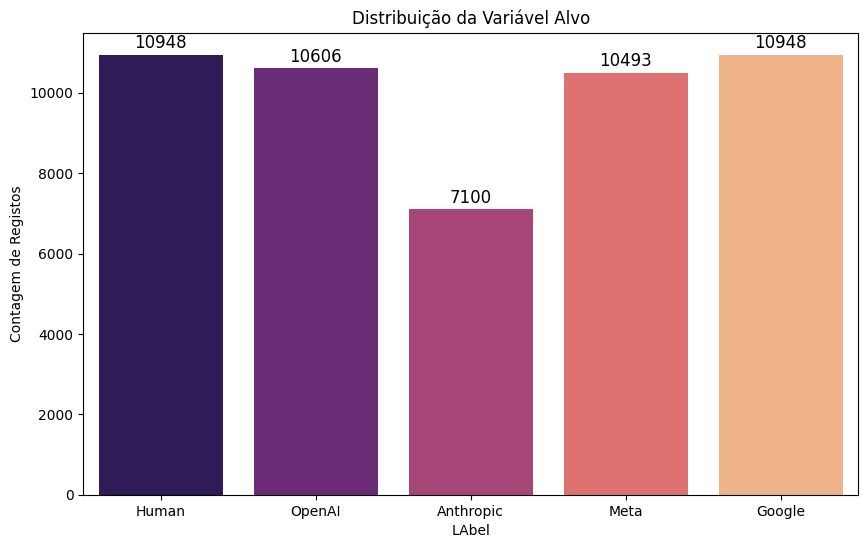

In [7]:
target_order = ['Human', 'OpenAI', 'Anthropic', 'Meta', 'Google']

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_master, x='Label', order=target_order, palette="magma")

plt.title('Distribuição da Variável Alvo')
plt.xlabel('LAbel')
plt.ylabel('Contagem de Registos')

# Adicionar as contagens em cima das barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points')
plt.show()